# A comparison of numerical optimizers
**Numerical Optimizers** are used in a wide variety of fields. Engineering, AI, physics, chemistry, the medical field and many more.

This is a quick guide on commonly used methods.

At first we will define a test problem we can use to compare our optimization algorythms:

$$
\min_{x \in \mathbb{R}^2} f(\vec{x})
$$
<div align="center">
where:
</div>
$$
f(\vec{x}) = x_1 + x_2 + (x_1^2 + x_2^2 -2)^2
$$

---

First we need to import some basic librarys and implement two functions we can use later to visualize our problem:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def create_contour_plot(func, constraint=None, title=None, ax=None, labels=True, large=False, bounds=None, levels=15, **kwargs):
    # create contour plot
    delta = 0.025
    if bounds is not None:
        x = np.arange(bounds[0,0], bounds[0,1], delta)
        y = np.arange(bounds[1,0], bounds[1,1], delta)
    elif large == True:
        x = np.arange(-2.5, 2.5, delta)
        y = np.arange(-2.5, 2.5, delta)
    else:
        x = np.arange(-1.5, 1.5, delta)
        y = np.arange(-1.5, 1.5, delta)
    X, Y = np.meshgrid(x, y)
    Z = func(np.stack((X, Y)), **kwargs)

    # create plot if necessary
    if ax is None:
        fig, ax = plt.subplots()

    CS = ax.contour(X, Y, Z, levels= levels)
    if labels:
        ax.clabel(CS, fontsize=10)

    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

    if title is not None:
        ax.set_title(title)

    if constraint is not None:
        constraint_Z = constraint(np.stack((X, Y)))
        ax.contour(X, Y, constraint_Z, levels=[0], colors='red')

def create_surface_plot(func, constraint=None, title=None, ax=None, labels=True, bounds=None, large = False, **kwargs):

    # create surface plot
    delta = 0.025
    if bounds is not None:
        x = np.arange(bounds[0,0], bounds[0,1], delta)
        y = np.arange(bounds[1,0], bounds[1,1], delta)
    elif large == True:
        x = np.arange(-2.5, 2.5, delta)
        y = np.arange(-2.5, 2.5, delta)
    else:
        x = np.arange(-1.5, 1.5, delta)
        y = np.arange(-1.5, 1.5, delta)
    X, Y = np.meshgrid(x, y)
    Z = func(np.stack((X, Y)), **kwargs)

    # create plot if necessary
    if ax is None:
        fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

    if title is not None:
        ax.set_title(title)

    ax.plot_surface(X, Y, Z, cmap='viridis')  


#### Derivatives

Since most optimizers are either **gradient based** (first derivative) or **hessian based** (second derivative), we need to define our function and thier derivatives in python.

Our functions **gradient** is:

$$
\nabla f(\vec{x}) =
\begin{bmatrix}
1 + 4x_1(x_1^2 + x_2^2 - 2) \\
1 + 4x_2(x_1^2 + x_2^2 - 2)
\end{bmatrix}
$$

Our 2. derivative or **Hessian matrix** is:

$$
\mathcal{H} = \nabla^2 f(\vec{x}) =
\begin{bmatrix}
12x_1^2 + 4x_2^2 - 8 & 8x_1x_2 \\
8x_1x_2 & 4x_1^2 + 12x_2^2 - 8
\end{bmatrix}
$$

***Disclaimer***: Usually these Derivatives are also computed numerically

In [2]:
def function(x):
    return (x[0] + x[1]) +  (x[0]**2 + x[1]**2 - 2)**2
    

def dfunction(x):
    return np.array([1 + 4*x[0]*(x[0]**2 + x[1]**2 - 2),
                     1 + 4*x[1]*(x[0]**2 + x[1]**2 - 2)])

def ddfunction(x):
    return np.array([[12*x[0]**2 + 4*x[1]**2 - 8, 8*x[0]*x[1]],
                     [8*x[0]*x[1]               , 4*x[0]**2 + 12*x[1]**2 - 8]])

No we are abled to take a look at the nature of our function.
First as a contour plot with isolines, then as a surface plot.

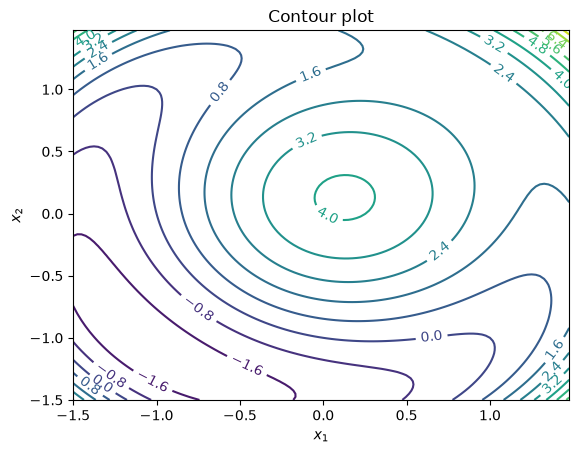

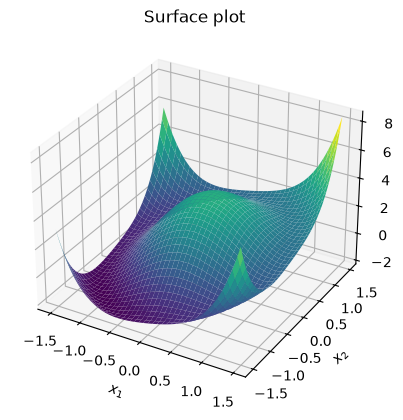

In [3]:
create_contour_plot(function, title = "Contour plot")
create_surface_plot(function, title="Surface plot")

## Stochastic Gradient Descent (SGD)
Our first optimization method is one of the simplest **first order optimizers**.

It works by updating the current $\vec{x}_n$ by the negative gradient $\nabla f(\vec{x})$ and hence creating $\vec{x}_{n+1}$

You can think of it as a ball that you put on a certain starting point on a surface, and starts to roll to the surfaces lowest point due to gravity. This is of course highly simplified, since we are neglecting intertia, friction, etc. but it still gives a good mental model to understand what is actually going on.

---

A **single step** or itreation using **SGD** is defined as followed:

$$
\vec{x}_{n+1} = \vec{x}_n - \alpha \cdot \nabla f(\vec{x}_n)
$$

As you probably noticed, there is one little thing in this formula that i did not talk about yet. The factor **$\alpha$**! This factor is also known as the learning rate. It is absolutely essential for SGD to work properly. 

---

For now we will set $\alpha = 0.1$ and implement a single SGD step. We will look at why we need that factor and how it affects our optimizer later.

In [4]:
def SGD_step(x_start, df, alpha):
    x_next = x_start - alpha * df(x_start)
    res = np.linalg.norm(df(x_start))
    return x_next, res

Now we can implement a working optimizer. This simply works by repeatedly doing SGD steps until a certain break condition is realized.

We will implement two **break conditions** in our optimizer:
1. `n_max`: Stop the iteration process after reaching a certain predifined **max** number of **steps** taken.
2. `res < tol`: Stop the iteration process after the **residual** is below a certain **tolerance**.

In this case the residual is the norm of the gradient $res = \left \lVert \nabla f(\vec{x}) \right \rVert$. 

We will also log the optimizers stats to plot them later.

In [5]:
def SGD_optimizer(x_start, function, df, n_max = 100, tol = 1e-10, alpha = 0.1):

    stats_list = []
    x = x_start
    
    for i in range(n_max):
        x_next, res = SGD_step(x, df, alpha = alpha)
        
        
        stats_list.append({
            "x1" : x[0],
            "x2" : x[1],
            "residual" : res,
            "Function Value" : function(x)
        })

        x = x_next

        if res < tol:
            break

    stats = pd.DataFrame(stats_list)
    
    return stats[["x1", "x2"]].iloc[-1], stats
    

We can now start an optimization run with $ x_{start} = 
\begin{bmatrix}
1.0 \\
1.3
\end{bmatrix}
$ and our break tolerance set to $0.0001$

By looking at our data we can observe, that our optimizer clearly follows the gradient of the function, hoping to reach a minima. With our current setup it took us 130 iterations to reach our required residual of $0.00001$

Iterations:  130
x1               -1.057528
x2               -1.057380
residual          0.000099
Function Value   -2.059015
Name: 130, dtype: float64


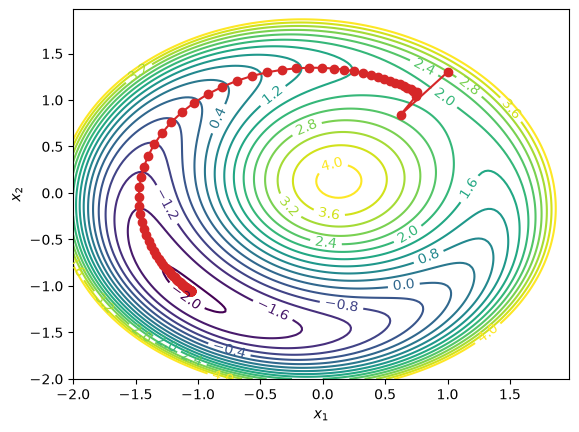

In [6]:
#Optimizer
result_SGD, stats_SGD = SGD_optimizer((1, 1.3), function, dfunction, n_max = 150, alpha = 0.1, tol = 1e-4)
print("Iterations: ", stats_SGD.iloc[-1].name)
print(stats_SGD.iloc[-1])

#Plot Function
fig, ax = plt.subplots()
levels = np.linspace(-2, 4, 16)
create_contour_plot(function, bounds = np.array([[-2.0, 2.0], [-2.0, 2.0]]), levels = levels, ax = ax)

#Plot Optimizer stats
ax.plot(stats_SGD["x1"], stats_SGD["x2"], "o-", color = "tab:red")

A residual of $0.000099$ and $x_{min} = \begin{bmatrix}-1.058\\-1.057\end{bmatrix}$ in $130$ iterations is already a good result. But we would like the optimizer to be a bit more efficient and reach the minima a bit faster. A seemingly obvious soulution would be to increase our step size $\alpha$ to $0.2$. This should make the optimizer konverge faster.

Iterations:  99
x1                0.798909
x2               -0.205396
residual          3.832955
Function Value    2.334743
Name: 99, dtype: float64


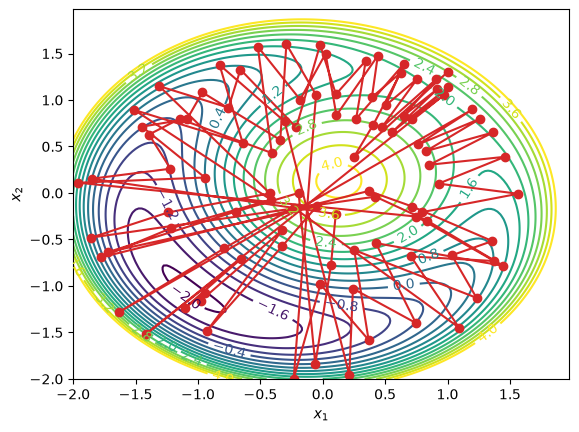

In [7]:
#Optimizer
result_SGD, stats_SGD = SGD_optimizer((1, 1.3), function, dfunction, n_max = 100, alpha = 0.2)
print("Iterations: ", stats_SGD.iloc[-1].name)
print(stats_SGD.iloc[-1])

#Plot Function
fig, ax = plt.subplots()
levels = np.linspace(-2, 4, 16)
create_contour_plot(function, bounds = np.array([[-2.0, 2.0], [-2.0, 2.0]]), levels = levels, ax = ax)

#Plot Optimizer stats
ax.plot(stats_SGD["x1"], stats_SGD["x2"], "o-", color = "tab:red")

Well... This does not look good! We have produced some **oscillatory behaviour** and our optimizer does not converge anymore. It seems like the step size is simply to big. 

This shows us that our optimizers behaviour is strongly dependent on the chosen step size. This is a big problem, since problems with bigger gradients also require smaller step sizes. 

The obvious solution would be to decrease $\alpha$ by a significant amount. So lets see what happens when we set $\alpha = 0.01$

Iterations:  999
x1               -1.059294
x2               -1.055610
residual          0.002464
Function Value   -2.059011
Name: 999, dtype: float64


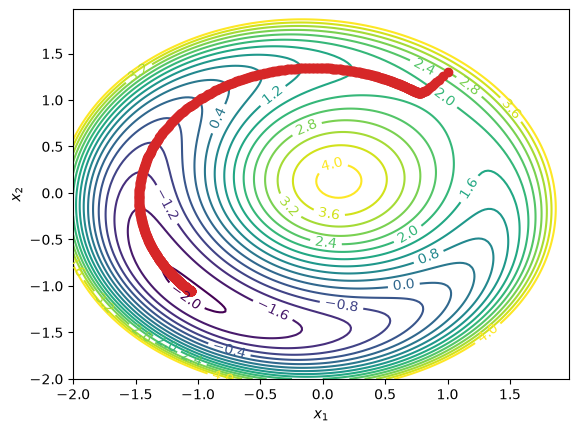

In [13]:
#Optimizer
result_SGD, stats_SGD = SGD_optimizer((1, 1.3), function, dfunction, n_max = 1000, alpha = 0.01)
print("Iterations: ", stats_SGD.iloc[-1].name)
print(stats_SGD.iloc[-1])

#Plot Function
fig, ax = plt.subplots()
levels = np.linspace(-2, 4, 16)
create_contour_plot(function, bounds = np.array([[-2.0, 2.0], [-2.0, 2.0]]), levels = levels, ax = ax)

#Plot Optimizer stats
ax.plot(stats_SGD["x1"], stats_SGD["x2"], "o-", color = "tab:red")

So reducing our step size to $\alpha = 0.01$ does not really help us to improove our optimizer in any way. We do not get more accurate results and with 1000 steps taken the optimizer simply became more inefficient.

This illustrates the problem with **SGD**: it is highly dependent on $\alpha$! Increasing the learning rate can help us improve efficiency, but we dont know how much we can increase it before we dont converge anymore. 

And for some problems even a certain small learning rate $\alpha$ can still be too large. So we are in some kind of cunundrum regarding our choice of alpha.

A rectification for this is to implement an adaptive learning rate. This means that our learning rate usually starts high and gets diminished over time. This can help, but is still quite dependent on the problem we are trying to optimize.

So what we actually need is a algorythm that changes its step size according to the calculated gradient. 

And this is where the next optimization alogorithm comes in clutch. The **Newton Mehod**

---

## Newton Method
The newton method looks quite similar to SGD at first. We have a certain $\vec{x}_{n}$ and a next iteration $\vec{x}_{n+1}$ which gets computed by taking a step into the negative direction of the gradient. 

The big difference here is, that our **step size is inversely proportional** to or gradient. This means that if we are on a very steep section of our problem topology, we wont take a huge step and overshoot a troph we would like to stay in. At the same time, if we are in a "flatter" section the optimizer takes slightly more steps and hence converges faster.

---

Single step using the newton method:

$$
\vec{x}_{n+1} = \vec{x}_n - \frac{f(\vec{x}_n)}{\nabla f(\vec{x}_n)}
$$

But there is another important fact have to take into account. SGD is (if convergent) converging towards a local minima. The newton method is a method to find the root of an equation. So we have to slightly adjust the newton method to search for zero points in our problems derivative.

$$
\vec{x}_{n+1} = \vec{x}_n - \nabla f(\vec{x}_n) \mathcal{H}^{-1}
$$

Now we are ready to implement a single newton step:

In [9]:
def newton_step(x_current, df, ddf, alpha = 1.0, **args):
    # evaluate derivatives
    dfcur = df(x_current, **args)
    ddfcur = ddf(x_current, **args)

    # invert Hesse matrix
    invH = np.linalg.inv(ddfcur)
    # calculate update
    xnext = x_current - alpha * np.matmul(dfcur, invH)

    # calculate gradient norm
    res = np.linalg.norm(dfcur)

    return xnext, res

We can implement the newton optimizer in a quite similar fashion as before.

In [14]:
def newton_optimizer(x_start, function, df, ddf, n_max = 100, tol = 1e-10, alpha = 1):
    stats_list = []
    x = x_start
    
    for i in range(n_max):
        x_next, res = newton_step(x, df, ddf, alpha = alpha)
        
        stats_list.append({
            "x1" : x[0],
            "x2" : x[1],
            "residual" : res,
            "Function Value" : function(x)
        })

        x = x_next

        if res < tol:
            break

    stats = pd.DataFrame(stats_list)
    
    return stats[["x1", "x2"]].iloc[-1], stats

Now that everything is implemented, let's see how our new optimizer performs!

Iterations:  14
x1               -1.057454e+00
x2               -1.057454e+00
residual          1.151639e-14
Function Value   -2.059015e+00
Name: 14, dtype: float64


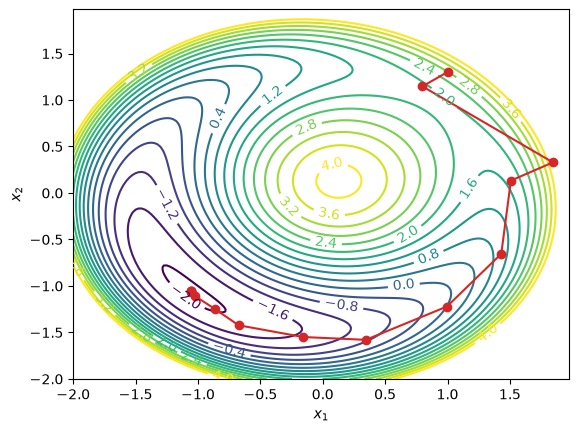

In [17]:
result_newton, stats_newton = newton_optimizer((1, 1.3), function, dfunction, ddfunction)
print("Iterations: ", stats_newton.iloc[-1].name)
print(stats_newton.iloc[-1])

fig, ax = plt.subplots()

levels = np.linspace(-2, 4, 16)
#levels = np.append(levels, [16,32,64])


create_contour_plot(function, bounds = np.array([[-2.0, 2.0], [-2.0, 2.0]]), levels = levels, ax = ax)
ax.plot(stats_newton["x1"], stats_newton["x2"], "o-", color = "tab:red")

Wonderful indeed! We can clearly observe how our optimizer adjusted its step size at the first step, due to the gradient being very steep there. But when moving along the bottom troph it increased again.
All this led to our optimizer only needing 14 steps!

Observant readers will have noticed an important handicap to the newton optimizer. It is a root finding algorythm we used to find minima by finding the root of the first derivative. But since a root of a derivative can be either a minima, maxima or saddle point we have no real